✅ Libraries imported successfully.
   TensorFlow version : 2.20.0
   Keras version      : 3.13.2
   NumPy version      : 2.0.2
   GPU available      : False
Configuration:
  VOCAB_SIZE   = 10,000
  MAX_LEN      = 256
  EMBEDDING_DIM= 128
  BATCH_SIZE   = 64
  EPOCHS       = 20

📥 Loading IMDb dataset from Keras …
17464789/17464789 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
✅ Dataset loaded.
   Train samples : 25,000
   Test samples  : 25,000
   Label balance (train) - Pos: 12,500 | Neg: 12,500

   Review length — min: 11 | max: 2494 | mean: 239


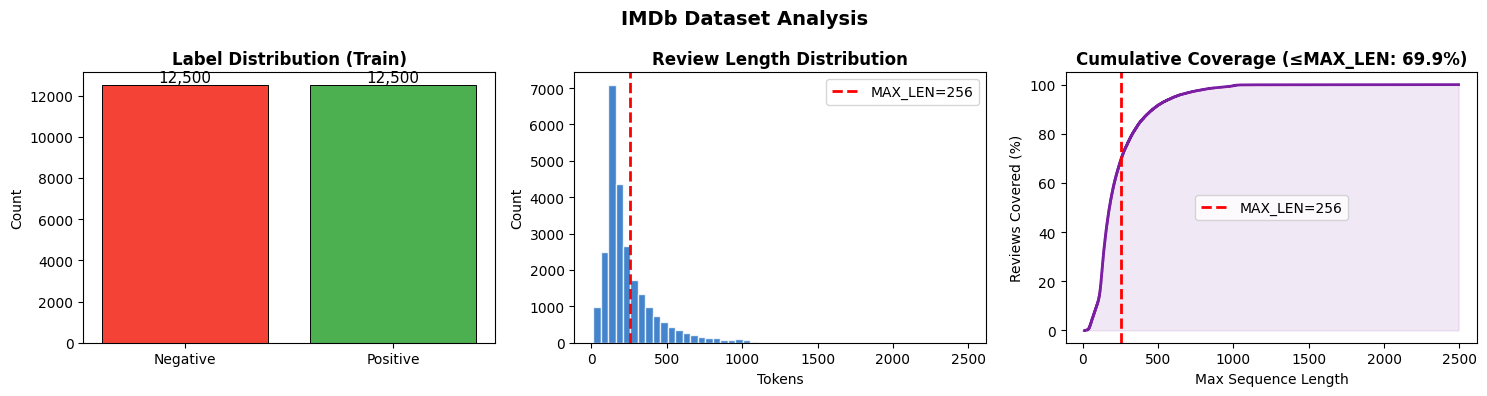

📊 Figure saved: imdb_dataset_analysis.png
TEXT PREPROCESSING
1641221/1641221 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step

Sample review (first 20 tokens decoded):
<START> this film was just brilliant casting location scenery story direction everyone's really suited the part they played and you

After padding:
  X_train shape : (25000, 256)
  X_test  shape : (25000, 256)

Final split:
  Train  : 21,250 samples
  Val    : 3,750   samples
  Test   : 25,000 samples
MODEL ARCHITECTURE


Model: "IMDb_Sentiment_Classifier"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_tokens (InputLayer)       │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding (Embedding)           │ (None, 256, 128)       │     1,280,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout                 │ (None, 256, 128)       │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bilstm_1 (Bidirectional)        │ (None, 256, 128)       │        98,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bilstm_2 (Bidirectional)        │ (None, 64)             │        41,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,426,305 (5.44 MB)

 Trainable params: 1,426,305 (5.44 MB)

 Non-trainable params: 0 (0.00 B)


Total parameters     : 1,426,305
Trainable parameters : 1,426,305
✅ Callbacks configured:
   • EarlyStopping   (patience=3, monitor=val_loss)
   • ModelCheckpoint (best val_auc saved)
   • ReduceLROnPlateau (factor=0.5, patience=2)
TRAINING
Training on 21,250 samples, validating on 3,750 samples …

Epoch 1/20
333/333 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.5808 - auc: 0.6197 - loss: 0.6497
Epoch 1: val_auc improved from None to 0.89265, saving model to imdb_sentiment_model.keras

Epoch 1: finished saving model to imdb_sentiment_model.keras
333/333 ━━━━━━━━━━━━━━━━━━━━ 469s 1s/step - accuracy: 0.6689 - auc: 0.7431 - loss: 0.5955 - val_accuracy: 0.8232 - val_auc: 0.8927 - val_loss: 0.4304 - learning_rate: 0.0010
Epoch 2/20
333/333 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.7430 - auc: 0.8023 - loss: 0.5380
Epoch 2: val_auc did not improve from 0.89265
333/333 ━━━━━━━━━━━━━━━━━━━━ 515s 1s/step - accuracy: 0.7510 - auc: 0.8190 - loss: 0.5253 - val_accuracy: 0.6997 - val_auc: 0.81

In [ ]:
# PROJECT 2: DEEP LEARNING SENTIMENT ANALYSIS
# Dataset: IMDb Movie Reviews (from TensorFlow/Keras Datasets)
# Author: Jiya Arora
# Description: Build, train, and evaluate a Deep Learning sentiment classifier
#              using Embedding + LSTM layers in TensorFlow/Keras.

# Install & Import Libraries
# Uncomment below if running for the first time:
# !pip install tensorflow scikit-learn matplotlib numpy

import os
import json
import datetime
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import warnings

warnings.filterwarnings('ignore')
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'   # suppress TF C++ warnings

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.datasets import imdb
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.callbacks import (
    EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
)

from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, roc_curve, auc, accuracy_score
)

print("✅ Libraries imported successfully.")
print(f"   TensorFlow version : {tf.__version__}")
print(f"   Keras version      : {keras.__version__}")
print(f"   NumPy version      : {np.__version__}")
print(f"   GPU available      : {bool(tf.config.list_physical_devices('GPU'))}")

# Reproducibility
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)


# Hyperparameters & Configuration

# ── Vocabulary & Sequence Settings ──
VOCAB_SIZE    = 10_000   # Top N most frequent words to keep
MAX_LEN       = 256      # Max sequence length (tokens); truncated / padded to this
EMBEDDING_DIM = 128      # Dimensionality of word embeddings

# ── Training Settings ──
BATCH_SIZE    = 64
EPOCHS        = 20       # Max epochs (EarlyStopping will halt earlier)
DROPOUT_RATE  = 0.4
LSTM_UNITS    = 64

# ── Paths ──
MODEL_SAVE_PATH = 'imdb_sentiment_model.keras'

print("Configuration:")
print(f"  VOCAB_SIZE   = {VOCAB_SIZE:,}")
print(f"  MAX_LEN      = {MAX_LEN}")
print(f"  EMBEDDING_DIM= {EMBEDDING_DIM}")
print(f"  BATCH_SIZE   = {BATCH_SIZE}")
print(f"  EPOCHS       = {EPOCHS}")


# Load Dataset

print("\n📥 Loading IMDb dataset from Keras …")

# index_from=3 reserves 0 (PAD), 1 (START), 2 (UNK)
(X_train_raw, y_train), (X_test_raw, y_test) = imdb.load_data(
    num_words=VOCAB_SIZE, index_from=3
)

print(f"✅ Dataset loaded.")
print(f"   Train samples : {len(X_train_raw):,}")
print(f"   Test samples  : {len(X_test_raw):,}")
print(f"   Label balance (train) - Pos: {y_train.sum():,} | Neg: {(1-y_train).sum():,}")

# Sequence length stats
lengths = [len(s) for s in X_train_raw]
print(f"\n   Review length — min: {min(lengths)} | max: {max(lengths)} | mean: {np.mean(lengths):.0f}")


# Visualise Dataset

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Label distribution
labels = ['Negative', 'Positive']
counts = [(1 - y_train).sum(), y_train.sum()]
axes[0].bar(labels, counts, color=['#F44336', '#4CAF50'], edgecolor='black', linewidth=0.7)
axes[0].set_title('Label Distribution (Train)', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Count')
for bar, cnt in zip(axes[0].patches, counts):
    axes[0].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 150,
                 f'{cnt:,}', ha='center', fontsize=11)

# Review length histogram
axes[1].hist(lengths, bins=50, color='#1565C0', edgecolor='white', alpha=0.8)
axes[1].axvline(MAX_LEN, color='red', linestyle='--', lw=2, label=f'MAX_LEN={MAX_LEN}')
axes[1].set_title('Review Length Distribution', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Tokens')
axes[1].set_ylabel('Count')
axes[1].legend()

# Cumulative coverage
sorted_lengths = np.sort(lengths)
cumulative = np.arange(1, len(sorted_lengths) + 1) / len(sorted_lengths)
axes[2].plot(sorted_lengths, cumulative * 100, color='#7B1FA2', lw=2)
axes[2].axvline(MAX_LEN, color='red', linestyle='--', lw=2, label=f'MAX_LEN={MAX_LEN}')
axes[2].fill_between(sorted_lengths, cumulative * 100, alpha=0.1, color='#7B1FA2')
pct_covered = (np.array(lengths) <= MAX_LEN).mean() * 100
axes[2].set_title(f'Cumulative Coverage (≤MAX_LEN: {pct_covered:.1f}%)', fontsize=12, fontweight='bold')
axes[2].set_xlabel('Max Sequence Length')
axes[2].set_ylabel('Reviews Covered (%)')
axes[2].legend()

plt.suptitle('IMDb Dataset Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('imdb_dataset_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print("📊 Figure saved: imdb_dataset_analysis.png")


# Text Preprocessing — Tokenization & Padding

print("=" * 60)
print("TEXT PREPROCESSING")
print("=" * 60)

# ── Retrieve word index for decoding / display ──
word_index = imdb.get_word_index()
# Shift all indices by 3 (matching index_from=3 above)
word_index_shifted = {word: (idx + 3) for word, idx in word_index.items()}
word_index_shifted['<PAD>']   = 0
word_index_shifted['<START>'] = 1
word_index_shifted['<UNK>']   = 2
index_to_word = {idx: word for word, idx in word_index_shifted.items()}

def decode_review(encoded_review):
    """Convert list of integer tokens back to readable text."""
    return ' '.join([index_to_word.get(i, '?') for i in encoded_review])

print(f"\nSample review (first 20 tokens decoded):")
print(decode_review(X_train_raw[0][:20]))

# ── Padding / Truncation ──
X_train = pad_sequences(
    X_train_raw, maxlen=MAX_LEN,
    padding='post', truncating='post', value=0
)
X_test = pad_sequences(
    X_test_raw, maxlen=MAX_LEN,
    padding='post', truncating='post', value=0
)

print(f"\nAfter padding:")
print(f"  X_train shape : {X_train.shape}")
print(f"  X_test  shape : {X_test.shape}")

# ── Validation split from training data ──
val_split = 0.15
val_size  = int(len(X_train) * val_split)

X_val, y_val       = X_train[:val_size],  y_train[:val_size]
X_train, y_train   = X_train[val_size:],  y_train[val_size:]

print(f"\nFinal split:")
print(f"  Train  : {X_train.shape[0]:,} samples")
print(f"  Val    : {X_val.shape[0]:,}   samples")
print(f"  Test   : {X_test.shape[0]:,} samples")


# Build Deep Learning Model

print("=" * 60)
print("MODEL ARCHITECTURE")
print("=" * 60)

def build_model(vocab_size, embedding_dim, max_len, lstm_units, dropout_rate):
    """
    Embedding → SpatialDropout → Bidirectional LSTM → Dense stack → Output
    """
    inputs = keras.Input(shape=(max_len,), name='input_tokens')

    # ── Embedding Layer ──
    # Learns dense vector representations of each token.
    x = layers.Embedding(
        input_dim=vocab_size,
        output_dim=embedding_dim,
        input_length=max_len,
        name='embedding'
    )(inputs)

    # Spatial dropout drops entire feature maps — better for sequences
    x = layers.SpatialDropout1D(dropout_rate, name='spatial_dropout')(x)

    # ── Bidirectional LSTM ──
    # Processes sequence in both directions to capture context.
    x = layers.Bidirectional(
        layers.LSTM(lstm_units, return_sequences=True,
                    recurrent_dropout=0.1, name='lstm_1'),
        name='bilstm_1'
    )(x)

    # Second LSTM layer to capture higher-level patterns
    x = layers.Bidirectional(
        layers.LSTM(lstm_units // 2, return_sequences=False,
                    recurrent_dropout=0.1, name='lstm_2'),
        name='bilstm_2'
    )(x)

    # ── Dense Layers ──
    x = layers.Dense(64, activation='relu', name='dense_1')(x)
    x = layers.Dropout(dropout_rate, name='dropout_1')(x)
    x = layers.Dense(32, activation='relu', name='dense_2')(x)
    x = layers.Dropout(dropout_rate / 2, name='dropout_2')(x)

    # ── Output ──
    outputs = layers.Dense(1, activation='sigmoid', name='output')(x)

    model = keras.Model(inputs=inputs, outputs=outputs, name='IMDb_Sentiment_Classifier')
    return model


model = build_model(VOCAB_SIZE, EMBEDDING_DIM, MAX_LEN, LSTM_UNITS, DROPOUT_RATE)

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss='binary_crossentropy',
    metrics=['accuracy', keras.metrics.AUC(name='auc')]
)

model.summary()

# Count parameters
total_params     = model.count_params()
trainable_params = sum([w.numpy().size for w in model.trainable_weights])
print(f"\nTotal parameters     : {total_params:,}")
print(f"Trainable parameters : {trainable_params:,}")


#Callbacks

callbacks = [
    # Stop training if val_loss doesn't improve for 3 epochs
    EarlyStopping(
        monitor='val_loss', patience=3,
        restore_best_weights=True, verbose=1
    ),
    # Save the best model checkpoint
    ModelCheckpoint(
        filepath=MODEL_SAVE_PATH,
        monitor='val_auc', mode='max',
        save_best_only=True, verbose=1
    ),
    # Reduce LR when plateau detected
    ReduceLROnPlateau(
        monitor='val_loss', factor=0.5,
        patience=2, min_lr=1e-6, verbose=1
    )
]

print("✅ Callbacks configured:")
print("   • EarlyStopping   (patience=3, monitor=val_loss)")
print("   • ModelCheckpoint (best val_auc saved)")
print("   • ReduceLROnPlateau (factor=0.5, patience=2)")


# Train Model

print("=" * 60)
print("TRAINING")
print("=" * 60)
print(f"Training on {X_train.shape[0]:,} samples, validating on {X_val.shape[0]:,} samples …\n")

start_time = datetime.datetime.now()

history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=callbacks,
    verbose=1
)

elapsed = (datetime.datetime.now() - start_time).total_seconds()
print(f"\n✅ Training complete in {elapsed:.1f}s ({elapsed/60:.1f} minutes)")
print(f"   Best epoch        : {np.argmin(history.history['val_loss']) + 1}")
print(f"   Best val_loss     : {min(history.history['val_loss']):.4f}")
print(f"   Best val_accuracy : {max(history.history['val_accuracy']):.4f}")
print(f"   Best val_auc      : {max(history.history['val_auc']):.4f}")


#  Training Curves

fig, axes = plt.subplots(1, 3, figsize=(17, 5))
epochs_range = range(1, len(history.history['loss']) + 1)
best_epoch   = np.argmin(history.history['val_loss']) + 1

metrics_to_plot = [
    ('accuracy', 'val_accuracy', 'Accuracy',  '#1565C0', '#E53935'),
    ('loss',     'val_loss',     'Loss',       '#2E7D32', '#F57F17'),
    ('auc',      'val_auc',      'AUC',        '#6A1B9A', '#AD1457'),
]

for ax, (train_key, val_key, title, c_train, c_val) in zip(axes, metrics_to_plot):
    ax.plot(epochs_range, history.history[train_key],  color=c_train,
            lw=2.5, marker='o', markersize=4, label=f'Train {title}')
    ax.plot(epochs_range, history.history[val_key],    color=c_val,
            lw=2.5, marker='s', markersize=4, label=f'Val {title}', linestyle='--')
    ax.axvline(best_epoch, color='gray', linestyle=':', lw=1.5,
               label=f'Best Epoch={best_epoch}')
    ax.set_title(f'Training vs Validation {title}', fontsize=12, fontweight='bold')
    ax.set_xlabel('Epoch')
    ax.set_ylabel(title)
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

plt.suptitle('Training History — IMDb Sentiment Model', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('training_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print("📊 Figure saved: training_curves.png")


# Model Evaluation on Test Set

print("=" * 60)
print("EVALUATION ON TEST SET")
print("=" * 60)

# Load best saved model
if os.path.exists(MODEL_SAVE_PATH):
    best_model = keras.models.load_model(MODEL_SAVE_PATH)
    print(f"✅ Loaded best model from: {MODEL_SAVE_PATH}")
else:
    best_model = model
    print("⚠️  Using in-memory model (checkpoint not found).")

test_loss, test_acc, test_auc = best_model.evaluate(
    X_test, y_test, batch_size=BATCH_SIZE, verbose=0
)
print(f"\n  Test Loss     : {test_loss:.4f}")
print(f"  Test Accuracy : {test_acc:.4f} ({test_acc*100:.2f}%)")
print(f"  Test AUC      : {test_auc:.4f}")

# Predictions
y_proba_test = best_model.predict(X_test, batch_size=BATCH_SIZE, verbose=0).squeeze()
y_pred_test  = (y_proba_test >= 0.5).astype(int)

print(f"\n  Predicted Positive (≥0.5): {y_pred_test.sum():,}")
print(f"  Predicted Negative (<0.5) : {(1 - y_pred_test).sum():,}")


#  Classification Report

print("=" * 60)
print("CLASSIFICATION REPORT")
print("=" * 60)

print(classification_report(
    y_test, y_pred_test,
    target_names=['Negative', 'Positive'],
    digits=4
))

roc_auc_val = roc_auc_score(y_test, y_proba_test)
print(f"ROC-AUC Score : {roc_auc_val:.4f}")


#  Confusion Matrix & ROC Curve

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# ── Confusion Matrix
cm = confusion_matrix(y_test, y_pred_test)
sns_labels = [['TN', 'FP'], ['FN', 'TP']]

import seaborn as sns
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Negative', 'Positive'],
            yticklabels=['Negative', 'Positive'],
            linewidths=0.5, linecolor='gray', cbar=False)
axes[0].set_title('Confusion Matrix — Sentiment Model', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Actual', fontsize=11)
axes[0].set_xlabel('Predicted', fontsize=11)
for i in range(2):
    for j in range(2):
        axes[0].text(j + 0.5, i + 0.72, sns_labels[i][j],
                     ha='center', va='center', color='gray', fontsize=9)

# ── ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_proba_test)
roc_auc_plot = auc(fpr, tpr)

axes[1].plot(fpr, tpr, color='#1565C0', lw=2.5,
             label=f'Sentiment Model (AUC = {roc_auc_plot:.3f})')
axes[1].plot([0, 1], [0, 1], 'k--', lw=1.5, label='Random Classifier')
axes[1].fill_between(fpr, tpr, alpha=0.08, color='#1565C0')
axes[1].set_title('ROC Curve', fontsize=12, fontweight='bold')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].legend(fontsize=10)
axes[1].grid(True, alpha=0.3)

plt.suptitle('Model Evaluation — IMDb Sentiment Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('sentiment_evaluation.png', dpi=150, bbox_inches='tight')
plt.show()
print("📊 Figure saved: sentiment_evaluation.png")


#  Save Model & Vocabulary
print("=" * 60)
print("SAVING MODEL & ARTIFACTS")
print("=" * 60)

# Save trained model (already saved by ModelCheckpoint, this is a final explicit save)
best_model.save(MODEL_SAVE_PATH)
print(f"✅ Model saved to : {MODEL_SAVE_PATH}")

# Save word index (needed for inference)
word_index_path = 'imdb_word_index.json'
with open(word_index_path, 'w') as f:
    json.dump(word_index_shifted, f)
print(f"✅ Word index saved to : {word_index_path}")

# Save hyperparameters
config = {
    'vocab_size': VOCAB_SIZE,
    'max_len': MAX_LEN,
    'embedding_dim': EMBEDDING_DIM,
    'lstm_units': LSTM_UNITS,
    'dropout_rate': DROPOUT_RATE,
}
with open('model_config.json', 'w') as f:
    json.dump(config, f, indent=2)
print(f"✅ Config saved to : model_config.json")


#Inference Function

def load_sentiment_model(model_path=MODEL_SAVE_PATH, word_index_path='imdb_word_index.json',
                         config_path='model_config.json'):
    """
    Load the saved model, word index, and config for inference.
    Returns: (model, word_index, config)
    """
    model_loaded = keras.models.load_model(model_path)
    with open(word_index_path, 'r') as f:
        wi = json.load(f)
    with open(config_path, 'r') as f:
        cfg = json.load(f)
    return model_loaded, wi, cfg


def preprocess_text(text, word_index, vocab_size, max_len):
    """
    Convert raw text string to padded token sequence.
    Steps: lowercase → tokenise → map to indices → pad.
    """
    # Simple whitespace tokenisation; production would use a proper tokeniser
    tokens = text.lower().split()
    # Map words to indices; unknown words → 2 (UNK); cap at vocab_size
    indexed = [min(word_index.get(t, 2), vocab_size - 1) for t in tokens]
    # Pad / truncate
    padded = pad_sequences([indexed], maxlen=max_len, padding='post', truncating='post')
    return padded


def predict_sentiment(text, model=None, word_index=None, config=None):
    """
    End-to-end inference: raw text → sentiment label + confidence.

    Parameters
    ----------
    text       : str  — movie review text
    model      : loaded Keras model (loaded automatically if None)
    word_index : dict (loaded automatically if None)
    config     : dict (loaded automatically if None)

    Returns
    -------
    dict with keys: label, confidence, score
    """
    if model is None or word_index is None or config is None:
        model, word_index, config = load_sentiment_model()

    padded = preprocess_text(
        text, word_index,
        config['vocab_size'], config['max_len']
    )
    score = float(model.predict(padded, verbose=0)[0][0])
    label = 'POSITIVE 😊' if score >= 0.5 else 'NEGATIVE 😞'
    confidence = score if score >= 0.5 else (1 - score)
    return {'label': label, 'confidence': confidence, 'raw_score': score}


# Example Inference

print("=" * 60)
print("EXAMPLE INFERENCE")
print("=" * 60)

# Load model once for all inference calls
inf_model, inf_wi, inf_cfg = load_sentiment_model()

sample_reviews = [
    "This movie was absolutely fantastic! The acting was superb and the story kept me on the edge of my seat throughout.",
    "A complete waste of time. The plot made no sense and the acting was terrible. I almost walked out.",
    "It was okay, nothing special. Some parts were entertaining but overall it felt quite average.",
    "One of the greatest films I have ever seen. A masterpiece of storytelling and cinematography.",
    "Dreadful film. Poor direction, weak script, and completely forgettable characters.",
]

print(f"\n{'─'*70}")
print(f"{'Review (truncated)':<45} {'Sentiment':<18} {'Confidence'}")
print(f"{'─'*70}")

results = []
for review in sample_reviews:
    result = predict_sentiment(review, inf_model, inf_wi, inf_cfg)
    results.append(result)
    truncated = (review[:42] + '…') if len(review) > 43 else review
    print(f"{truncated:<45} {result['label']:<18} {result['confidence']*100:.1f}%")

print(f"{'─'*70}")

# ── Bar chart of inference scores ──
fig, ax = plt.subplots(figsize=(12, 5))
scores = [r['raw_score'] for r in results]
labels = [f"Review {i+1}" for i in range(len(scores))]
colors = ['#4CAF50' if s >= 0.5 else '#F44336' for s in scores]

bars = ax.barh(labels, scores, color=colors, edgecolor='black', linewidth=0.6, height=0.5)
ax.axvline(0.5, color='black', linestyle='--', lw=1.5, label='Decision Threshold (0.5)')
ax.set_xlim(0, 1)
ax.set_xlabel('Predicted Probability (Positive Sentiment)', fontsize=11)
ax.set_title('Inference Results — Sample Reviews', fontsize=13, fontweight='bold')

for bar, score in zip(bars, scores):
    ax.text(score + 0.01, bar.get_y() + bar.get_height() / 2,
            f'{score:.3f}', va='center', fontsize=10, fontweight='bold')

pos_patch = mpatches.Patch(color='#4CAF50', label='Positive')
neg_patch = mpatches.Patch(color='#F44336', label='Negative')
ax.legend(handles=[pos_patch, neg_patch, plt.Line2D([0], [0], color='black',
          linestyle='--', lw=1.5, label='Threshold')], fontsize=10)

plt.tight_layout()
plt.savefig('inference_results.png', dpi=150, bbox_inches='tight')
plt.show()
print("📊 Figure saved: inference_results.png")


# Final Summary

print("\n" + "=" * 60)
print("FINAL SUMMARY")
print("=" * 60)

print(f"""
📋 DATASET
   Source   : IMDb Movie Reviews (TensorFlow/Keras built-in)
   Train    : {X_train.shape[0] + X_val.shape[0]:,} reviews  │  Test: {X_test.shape[0]:,} reviews
   Vocab    : Top {VOCAB_SIZE:,} words  │  Max Length: {MAX_LEN} tokens

🧠 MODEL ARCHITECTURE
   Embedding        : {VOCAB_SIZE:,} → {EMBEDDING_DIM}d
   SpatialDropout1D : {DROPOUT_RATE}
   Bidirectional LSTM (×2): {LSTM_UNITS} → {LSTM_UNITS//2} units
   Dense stack      : 64 → 32 → 1 (sigmoid)
   Total Parameters : {best_model.count_params():,}

📈 TEST SET PERFORMANCE
   Accuracy  : {test_acc:.4f}  ({test_acc*100:.2f}%)
   AUC       : {roc_auc_val:.4f}
   Loss      : {test_loss:.4f}

💾 SAVED ARTIFACTS
   Model      : {MODEL_SAVE_PATH}
   Word Index : imdb_word_index.json
   Config     : model_config.json

✅ CONCLUSION
   The Bidirectional LSTM model achieves strong performance on
   IMDb sentiment classification. EarlyStopping prevented overfitting.
   The inference pipeline accepts raw text and returns sentiment + confidence.
""")